In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
models = ["alibaba_cloud/qwen3_235b.tsv", "alibaba_cloud/qwen_qwq.tsv",
          "anthropic/claude_35_haiku.tsv","anthropic/claude_37_sonnet.tsv", 
          "deepseek/deepseek_v3.tsv", "deepseek/deepseek_r1.tsv",
          "openai/gpt35_turbo.tsv", "openai/gpt4o.tsv", "openai/gpt4o_turbo.tsv", "openai/gpt4o_mini.tsv", "openai/o3_mini.tsv", "openai/gpt45_preview.tsv",
          "vertex/gemini_15_pro.tsv", "vertex/gemini_25_flash.tsv",
          "xai/grok2.tsv", 
          "meta/llama31_8b.tsv", "meta/llama31_405b.tsv", "meta/llama32_3b.tsv", "meta/llama33_70b.tsv", "meta/llama4_maverick.tsv",
          "mistral/mistral_7b.tsv",
          "microsoft/phi4.tsv"]
model_names = ["Qwen 3 235b", "Qwen QwQ 32b",
               "Claude 3.5 Haiku", "Claude 3.7 Sonnet", 
               "DeepSeek-V3", "DeepSeek-R1",
               "GPT 3.5 Turbo", "GPT 4o", "GPT 4o Turbo", "GPT 4o Mini", "o3 Mini", "GPT 4.5 Preview",
               "Gemini 1.5 Pro", "Gemini 2.5 Flash",
               "Grok 2", 
               "Llama 3.1:8b", "Llama 3.1:405b", "Llama 3.2:3b", "Llama 3.3:70b", "Llama 4 Maverick",
               "Mistral:7b",
               "Phi 4"]

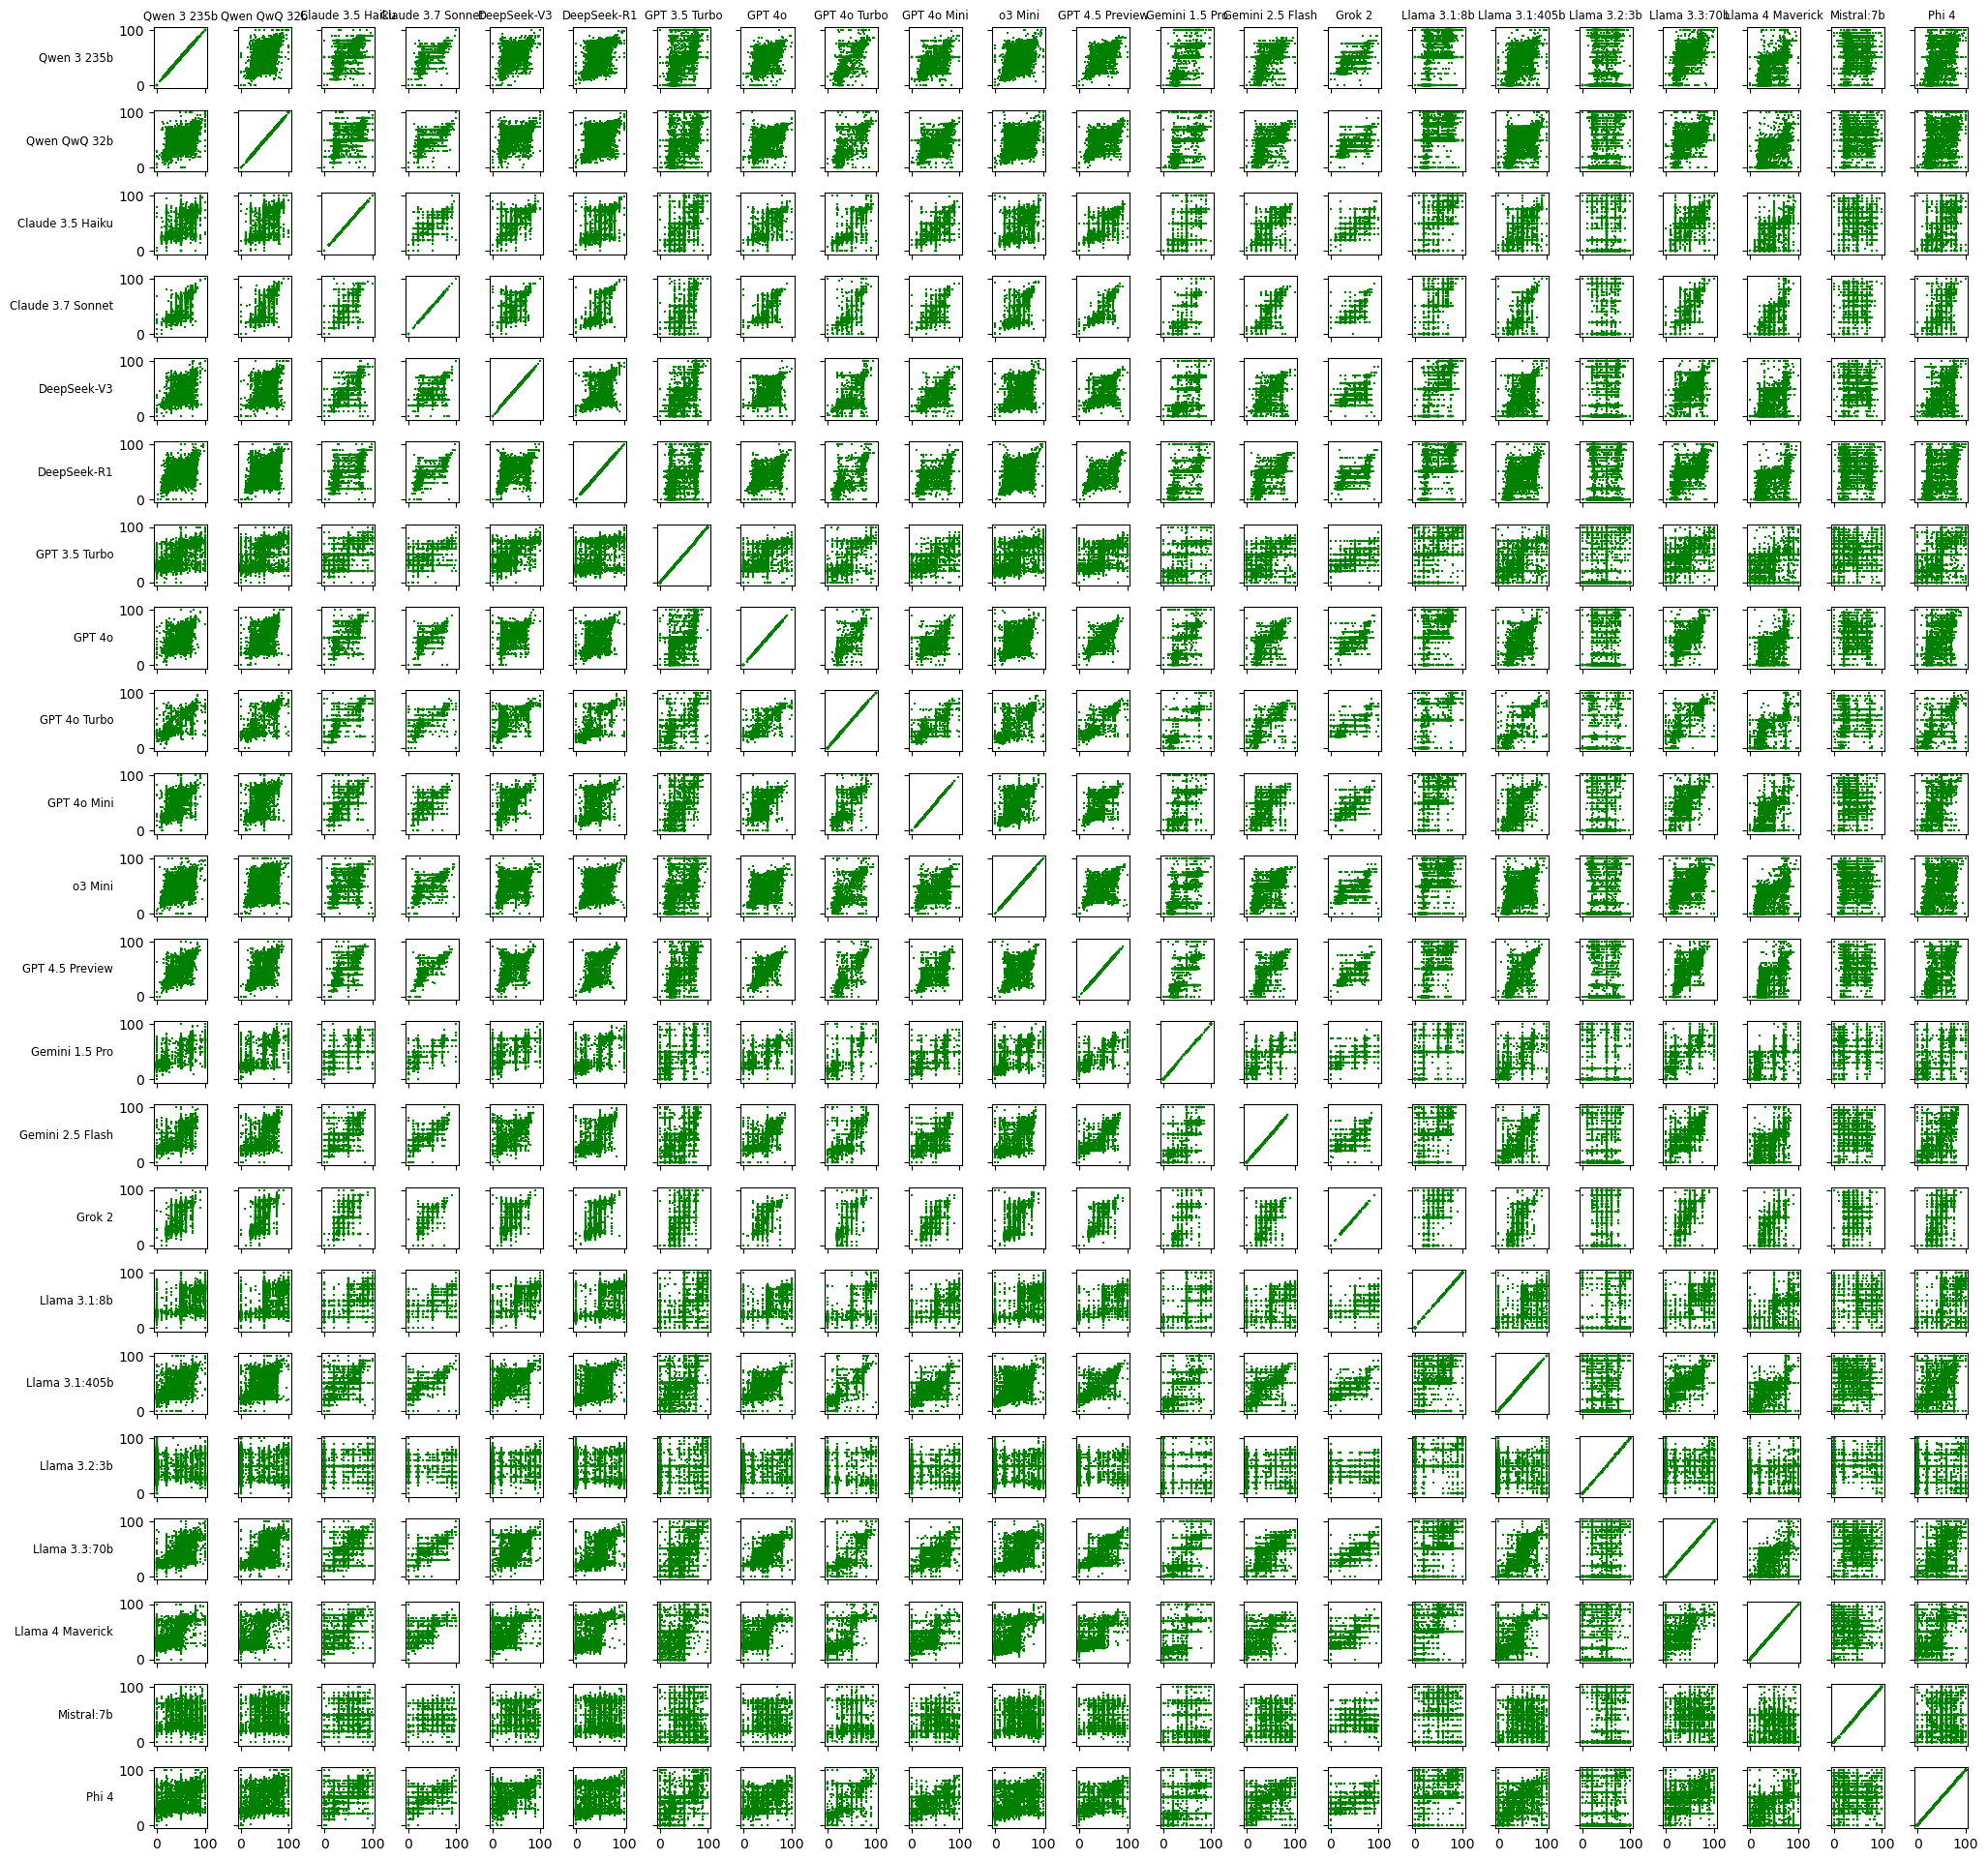

In [3]:
fig, ax = plt.subplots(len(models), len(models), sharex=True, sharey=True, figsize=(20,20))

for i in range(0, len(models)):
    for j in range(0, len(models)):
        
        df1 = pd.read_csv("../../data/processed/models/" + models[i], delimiter="\t")
        df2 = pd.read_csv("../../data/processed/models/" + models[j], delimiter="\t")


        #try:
        #    df1_list = df1.iloc[:, 2].to_list()
        #    df1_list = [float(x.strip()) if "nan" not in x else np.nan for x in df1_list]
        #    #print(len(df1_list))

        #    df2_list = df2.iloc[:, 2].to_list()
        #    df2_list = [float(x.strip()) if "nan" not in x else np.nan for x in df2_list]
        #    #print(len(df2_list))

        #except:
        df2_list = [float(x) for x in df2.iloc[:, 2].to_list()]
        df1_list = [float(x) for x in df1.iloc[:, 2].to_list()]

        ax[i,j].scatter(df1_list, df2_list, marker="+", color="green", s=2)

for axis, col in zip(ax[0], model_names):
    axis.set_title(col.replace(".tsv", ""),size="small")

for axis, row in zip(ax[:,0], model_names):
    axis.set_ylabel(row.replace(".tsv", ""),size="small",ha='right', va='center',rotation=0)


fig.tight_layout()
# tight_layout doesn't take these labels into account. We'll need 
# to make some room. These numbers are are manually tweaked. 
# You could automatically calculate them, but it's a pain.
fig.subplots_adjust(left=0.05, top=0.95)
